# WiFi Sensing: EDA & Data Setup
This notebook covers the initial loading, cleaning, and exploratory analysis of the CSI (Channel State Information) dataset.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
%matplotlib inline

## 1. Load Data
Loading the primary training set and the unlabeled test set.

In [12]:
train_df = pd.read_csv('data/raw/train_nt.csv', sep=';')
test_df = pd.read_csv('data/raw/test_nolabels_nt.csv', sep=';')

print(f'Train samples: {len(train_df)}')
print(f'Test samples: {len(test_df)}')
train_df.head()

Train samples: 12888
Test samples: 3223


,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,0,-5703,-88,-88,0,0,4,5,7,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,1,0,1835,-91,-88,0,0,-10,4,-7,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,2,0,4,-86,-87,0,0,5,14,5,...,10,7,16,7,13,11,16,11,13,9
3,3,52464,1259,-81,-71,0,0,-1,12,1,...,13,-7,14,-6,17,-6,16,-7,16,2
4,4,0,900,-82,-76,0,0,9,2,9,...,6,14,4,16,7,14,7,14,2,2


## 2. Local Validation Split
Creating a 90/10 split to monitor overfitting locally.

In [13]:
X = train_df.drop('position', axis=1)
y = train_df['position']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f'Validation set size: {len(X_val)}')

Validation set size: 1289


## 3. Verify Class Balance

C:\Users\laura\AppData\Local\Temp\ipykernel_47364\424979199.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='magma')


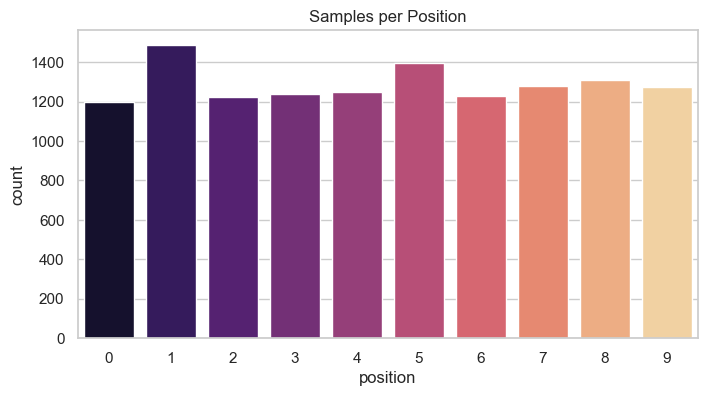

In [14]:
plt.figure(figsize=(8, 4))
sns.countplot(x=y, palette='magma')
plt.title('Samples per Position')
plt.show()

## 4. Metadata Analysis
Analyzing Angle of Arrival (AoA) and RSSI (Signal Strength).

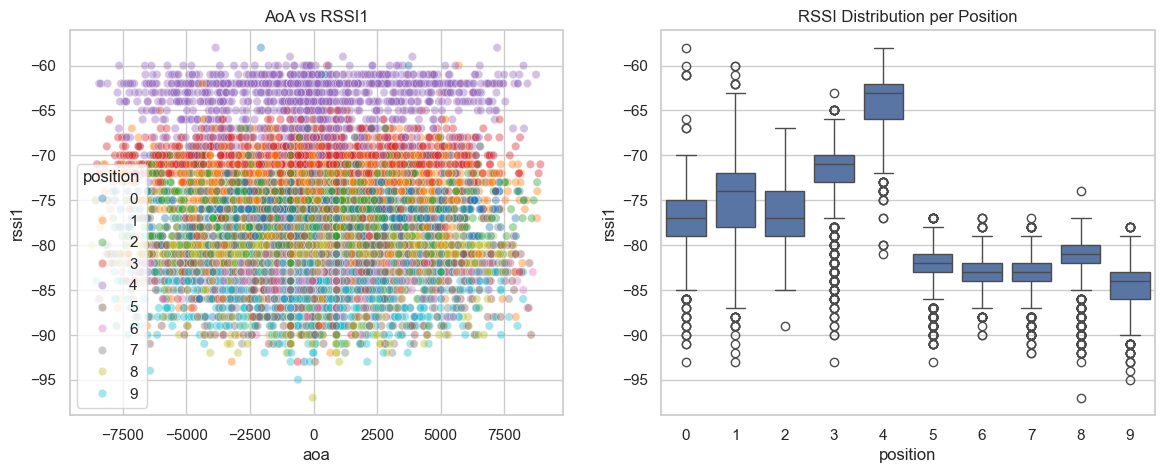

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=train_df, x='aoa', y='rssi1', hue='position', ax=ax[0], alpha=0.4, palette='tab10')
ax[0].set_title('AoA vs RSSI1')

sns.boxplot(data=train_df, x='position', y='rssi1', ax=ax[1])
ax[1].set_title('RSSI Distribution per Position')
plt.show()

## 5. Visualize Raw CSI
Plotting Magnitude across subcarriers for two different antennas/positions.

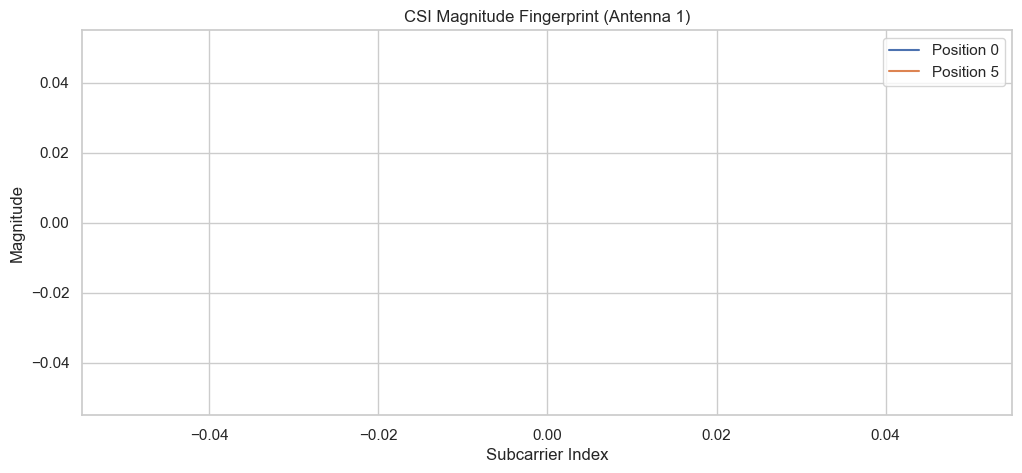

In [18]:
def get_mag_cols(antenna_idx):
    return [col for col in train_df.columns if f'mag' in col and f'_{antenna_idx}' in col]

plt.figure(figsize=(12, 5))
for pos in [0, 5]:
    sample = train_df[train_df['position'] == pos].iloc[0]
    mags = sample[get_mag_cols(1)]
    plt.plot(mags.values, label=f'Position {pos}')

plt.title('CSI Magnitude Fingerprint (Antenna 1)')
plt.xlabel('Subcarrier Index')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

## 6. Unsupervised Clustering
Checking if the CSI data naturally separates into 10 groups.

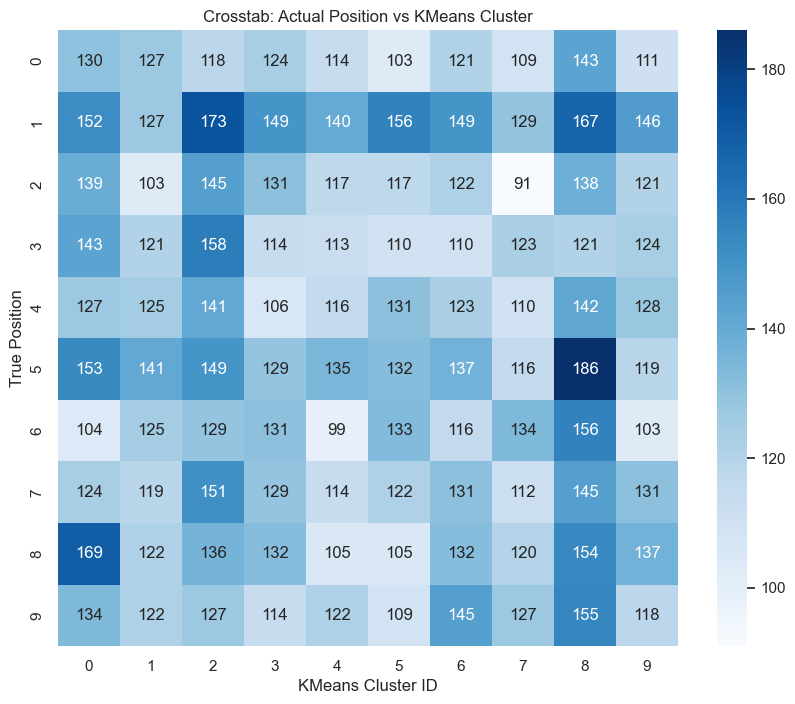

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 8))
conf_matrix = pd.crosstab(y, clusters)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Crosstab: Actual Position vs KMeans Cluster')
plt.xlabel('KMeans Cluster ID')
plt.ylabel('True Position')
plt.show()

## 7. Outlier Detection (DBSCAN)
Identifying noise in the signal environment.

Detected Outliers: 7 (0.05%)


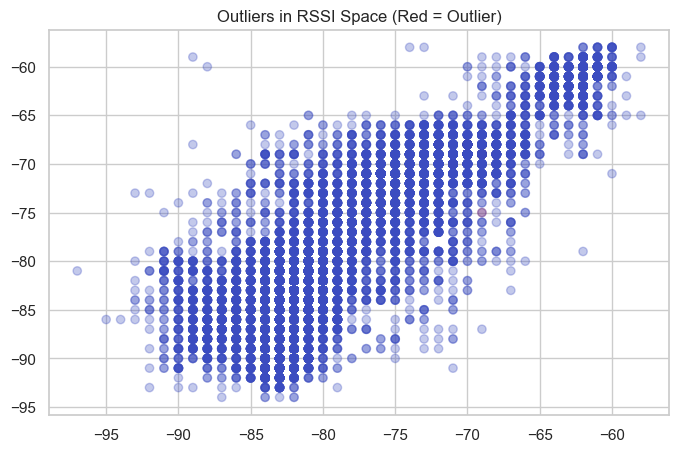

In [21]:
dbscan = DBSCAN(eps=15, min_samples=5)
outlier_labels = dbscan.fit_predict(X_scaled)

n_outliers = np.sum(outlier_labels == -1)
print(f'Detected Outliers: {n_outliers} ({100*n_outliers/len(X):.2f}%)')

plt.figure(figsize=(8, 5))
plt.scatter(train_df['rssi1'], train_df['rssi2'], c=(outlier_labels == -1), cmap='coolwarm', alpha=0.3)
plt.title('Outliers in RSSI Space (Red = Outlier)')
plt.show()